##  Install Packages

In [ ]:
# 1. NLP and Transformers
!pip install datasets==2.18.0 transformers accelerate sentencepiece

# 2. Audio Processing
!pip install openai-whisper librosa soundfile

# 3. Evaluation and Metrics
!pip install evaluate seqeval rouge_score sacrebleu jiwer

!pip install pandas  scikit-learn matplotlib seaborn nltk tqdm

!pip install numpy==1.26.4


##  Import Libraries

In [ ]:
#  Global Imports
import os, json, re, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForTokenClassification, AutoModelForSeq2SeqLM,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    DataCollatorForTokenClassification, DataCollatorForSeq2Seq,
    EarlyStoppingCallback, set_seed,
)
from datasets import load_dataset, Dataset, DatasetDict
import evaluate

warnings.filterwarnings("ignore")
set_seed(42)

# ─── Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

#  Paths
BASE_DIR   = Path("./nlu_models")
BASE_DIR.mkdir(exist_ok=True)

MODEL_DIRS = {
    "intent":     BASE_DIR / "intent_classifier",
    "ner":        BASE_DIR / "ner_model",
    "summarizer": BASE_DIR / "summarizer",
    "action":     BASE_DIR / "action_extractor",
    "embedding":  BASE_DIR / "sentence_embedder",
    "stt":        BASE_DIR / "whisper_stt",
}
for p in MODEL_DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
print(f" Models will be saved in: {BASE_DIR.absolute()}")


  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
 Models will be saved in: /content/nlu_models



#  Module 1: Intent Classification

### 1.1 Load & Explore Dataset

In [ ]:
ds_intent_raw = load_dataset("clinc_oos", "plus")
print(ds_intent_raw)


Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})


In [ ]:
print(ds_intent_raw["train"].features)

df_sample = pd.DataFrame(ds_intent_raw["train"].select(range(5)))
display(df_sample)


 Features: {'text': Value(dtype='string', id=None), 'intent': ClassLabel(names=['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time', 'weather', 'redeem_rewards', 'interest_rate', 'gas_type', 'accept_reservations', 'smart_home', 'user_name', 'report_lost_card', 'repeat', 'whisper_mode', 'what_are_your_hobbies', 'order', 'jump_start', 'schedule_meeting', 'meeting_schedule', 'freeze_account', 'what_song', 'meaning_of_life', 'restaurant_reservation', 'traffic', 'make_call', 'text', 'bill_balance', 'improve_credit_score', 'change_language', 'no', 'measurement_conversion', 'timer', 'flip_coin', 'do_you_have_pets', 'balance', 'tell_joke', 'last_maintenance', 'exchange_rate', 'uber', 'car_rental', 'credit_limit', 'oos', 'shopping_list', 'expiration_date', 'routing', 'meal_suggestion', 'tire_change', 'todo_list', 'card_declined', 'rewards_balance', 'change_accent', 'vaccines', 'reminder_update', 'food_last', 'change_ai_name', 'bill_due', 'who_do_you_work_for', '

,text,intent
0,what expression would i use to say i love you ...,61
1,can you tell me how to say 'i do not speak muc...,61
2,"what is the equivalent of, 'life is good' in f...",61
3,"tell me how to say, 'it is a beautiful morning...",61
4,"if i were mongolian, how would i say that i am...",61


### 1.2 EDA — Exploratory Data Analysis

In [ ]:
df_intent_train = pd.DataFrame(ds_intent_raw["train"])
df_intent_val   = pd.DataFrame(ds_intent_raw["validation"])
df_intent_test  = pd.DataFrame(ds_intent_raw["test"])

print(f"Train size:      {len(df_intent_train):,}")
print(f"Validation size: {len(df_intent_val):,}")
print(f"Test size:       {len(df_intent_test):,}")

Train size:      15,250
Validation size: 3,100
Test size:       5,500


In [ ]:
#  Label mapping
label_names_intent = ds_intent_raw["train"].features["intent"].names
print(f"\n  Intent Labels ({len(label_names_intent)}): {label_names_intent}")


  Intent Labels (151): ['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time', 'weather', 'redeem_rewards', 'interest_rate', 'gas_type', 'accept_reservations', 'smart_home', 'user_name', 'report_lost_card', 'repeat', 'whisper_mode', 'what_are_your_hobbies', 'order', 'jump_start', 'schedule_meeting', 'meeting_schedule', 'freeze_account', 'what_song', 'meaning_of_life', 'restaurant_reservation', 'traffic', 'make_call', 'text', 'bill_balance', 'improve_credit_score', 'change_language', 'no', 'measurement_conversion', 'timer', 'flip_coin', 'do_you_have_pets', 'balance', 'tell_joke', 'last_maintenance', 'exchange_rate', 'uber', 'car_rental', 'credit_limit', 'oos', 'shopping_list', 'expiration_date', 'routing', 'meal_suggestion', 'tire_change', 'todo_list', 'card_declined', 'rewards_balance', 'change_accent', 'vaccines', 'reminder_update', 'food_last', 'change_ai_name', 'bill_due', 'who_do_you_work_for', 'share_location', 'international_visa', 'calendar', 'tran

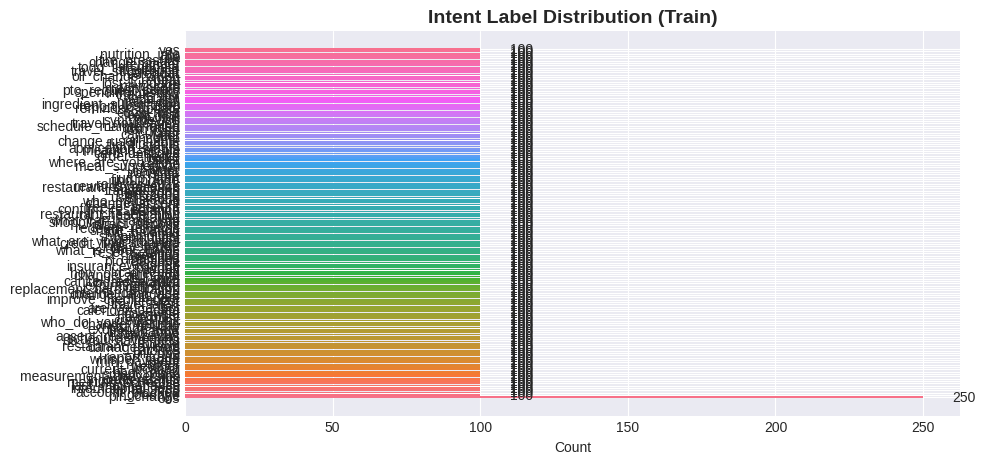

In [ ]:
#Distribution plot
label_counts = df_intent_train["intent"].value_counts()
label_names_mapped = [label_names_intent[i] for i in label_counts.index]

plt.figure(figsize=(10, 5))
plt.barh(label_names_mapped, label_counts.values, color=sns.color_palette("husl", len(label_counts)))

plt.title("Intent Label Distribution (Train)", fontsize=14, fontweight="bold")
plt.xlabel("Count")

for i, v in enumerate(label_counts.values):
    plt.text(v + 10, i, str(v), va="center")

plt.show()

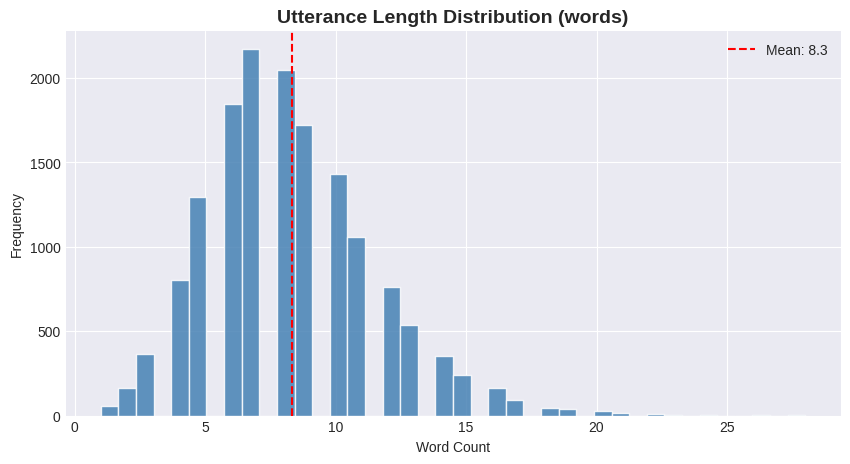

In [ ]:
# Utterance length distribution
df_intent_train["utt_len"] = df_intent_train["text"].str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(df_intent_train["utt_len"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)

mean_len = df_intent_train["utt_len"].mean()
plt.axvline(mean_len, color="red", linestyle="--", label=f'Mean: {mean_len:.1f}')

plt.title("Utterance Length Distribution (words)", fontsize=14, fontweight="bold")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()


plt.show()

### 1.3 Data Cleaning

In [ ]:
import re
import pandas as pd
from datasets import Dataset, DatasetDict

def clean_text(text):

    if not isinstance(text, str):
        return ""

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove unwanted characters
    text = re.sub(r"[^\w\s\?\!\.\,\;\:\'\-]", "", text)

    # Convert to lowercase
    text = text.lower()

    return text


def clean_dataset_split(dataset_split):

    df = pd.DataFrame(dataset_split)
    original_length = len(df)

    # Clean text column
    df["text"] = df["text"].apply(clean_text)

    # Remove empty or very short samples
    df = df[df["text"].str.len() > 2].reset_index(drop=True)

    # Remove very long outliers
    df["word_count"] = df["text"].str.split().str.len()
    df = df[df["word_count"] <= 200].drop(columns=["word_count"])

    print(f"Removed {original_length - len(df)} rows ({original_length} -> {len(df)})")

    # Return cleaned dataset with correct schema
    return Dataset.from_pandas(df[["text", "intent"]], preserve_index=False)



ds_intent_clean = DatasetDict({
    "train": clean_dataset_split(ds_intent_raw["train"]),
    "validation": clean_dataset_split(ds_intent_raw["validation"]),
    "test": clean_dataset_split(ds_intent_raw["test"]),
})

print(ds_intent_clean)

Removed 2 rows (15250 -> 15248)
Removed 1 rows (3100 -> 3099)
Removed 1 rows (5500 -> 5499)
DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15248
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3099
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5499
    })
})


### 1.4 Tokenization with RoBERTa

In [ ]:
#  RoBERTa Tokenization
from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"
print(f"Loading tokenizer: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128

def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


ds_intent_tok = ds_intent_clean.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],  # remove raw text after tokenization
    desc="Tokenizing dataset"
)

# Rename label column to match Transformers expectations
ds_intent_tok = ds_intent_tok.rename_column("intent", "labels")

# Set format for PyTorch
ds_intent_tok.set_format("torch")

print(ds_intent_tok)

Loading tokenizer: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset:   0%|          | 0/15248 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/3099 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/5499 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 15248
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 3099
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5499
    })
})


### 1.5 Fine-Tuning RoBERTa for Intent Classification

In [ ]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "roberta-base"

# Number of labels
num_labels = len(label_names_intent)

# Label mappings
id2label = {i: label for i, label in enumerate(label_names_intent)}
label2id = {label: i for i, label in enumerate(label_names_intent)}

# Load model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# Move model to device
model.to(DEVICE)

# Parameter statistics
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Total parameters:     124,761,751
Trainable parameters: 124,761,751


In [ ]:
#  Metrics
import numpy as np
import evaluate
from sklearn.metrics import classification_report, confusion_matrix

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )["f1"]

    return {
        "accuracy": accuracy,
        "f1_weighted": f1
    }


#  Training Arguments
from transformers import TrainingArguments

output_dir = str(MODEL_DIRS["intent"])

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,

    warmup_steps=500,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,

    logging_steps=50,

    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
)


#  Trainer
from transformers import Trainer, DataCollatorWithPadding, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_intent_tok["train"],
    eval_dataset=ds_intent_tok["validation"],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


#  Training
print(f"Model: {MODEL_NAME}")
print(f"Train samples: {len(ds_intent_tok['train']):,}")
print(f"Validation samples: {len(ds_intent_tok['validation']):,}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")
print()

train_result = trainer.train()

print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Runtime (s):   {train_result.metrics['train_runtime']:.0f}")
print(f"Samples/sec:   {train_result.metrics['train_samples_per_second']:.1f}")

Model: roberta-base
Train samples: 15,248
Validation samples: 3,099
Epochs: 5
Batch size: 32
Learning rate: 2e-05



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,3.239554,2.589961,0.812197,0.794019
2,0.880378,0.663371,0.940949,0.938404
3,0.320841,0.310702,0.958696,0.958211
4,0.150101,0.236562,0.961278,0.960979
5,0.127803,0.229940,0.962569,0.962262


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training loss: 1.3444
Runtime (s):   555
Samples/sec:   137.3


### 1.6 Testing & Evaluation — Intent Classification

In [ ]:
print("Evaluating on TEST set")

test_results = trainer.evaluate(ds_intent_tok["test"])

print("\nTest Results:")
for k, v in test_results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")

Evaluating on TEST set



Test Results:
eval_loss: 0.5378
eval_accuracy: 0.9014
eval_f1_weighted: 0.8973
eval_runtime: 9.2076
eval_samples_per_second: 597.2250
eval_steps_per_second: 9.3400
epoch: 5.0000


In [ ]:
predictions_output = trainer.predict(ds_intent_tok["test"])

y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

print("\nFull Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_names_intent
))


Full Classification Report:
                           precision    recall  f1-score   support

       restaurant_reviews       0.87      0.87      0.87        30
           nutrition_info       0.77      1.00      0.87        30
          account_blocked       0.97      0.93      0.95        30
           oil_change_how       0.88      0.97      0.92        30
                     time       0.91      1.00      0.95        30
                  weather       0.86      1.00      0.92        30
           redeem_rewards       0.93      0.83      0.88        30
            interest_rate       0.78      0.97      0.87        30
                 gas_type       0.97      1.00      0.98        30
      accept_reservations       0.87      0.90      0.89        30
               smart_home       0.75      1.00      0.86        30
                user_name       0.94      0.97      0.95        30
         report_lost_card       1.00      0.93      0.97        30
                   repeat       

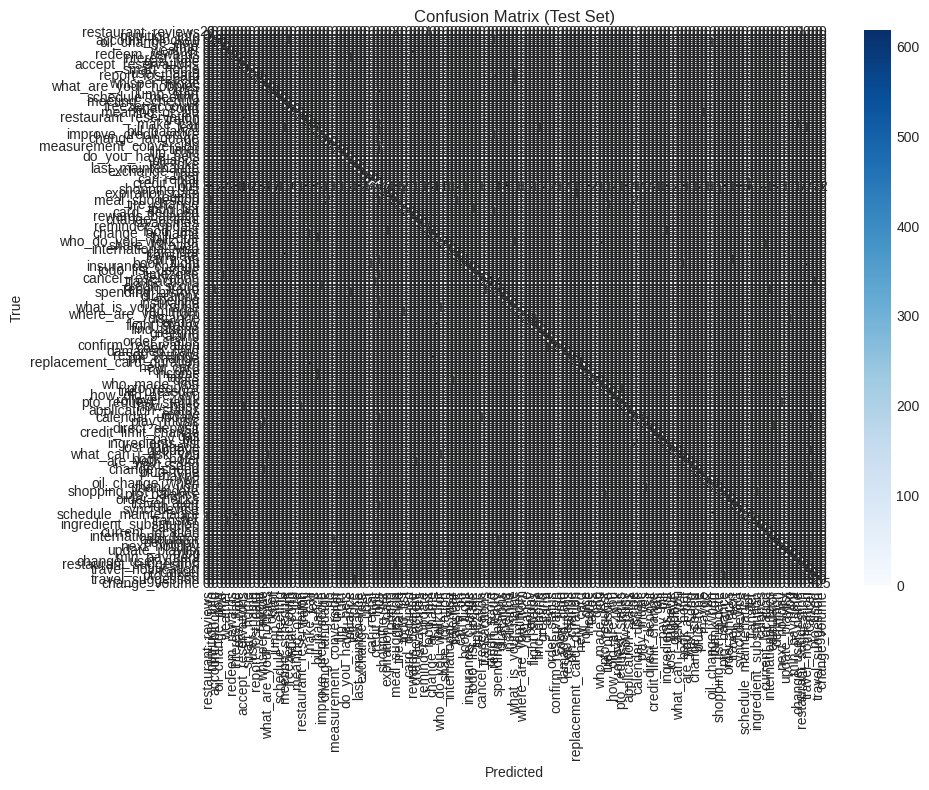

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names_intent,
    yticklabels=label_names_intent,
    ax=ax
)

ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.tight_layout()
plt.show()

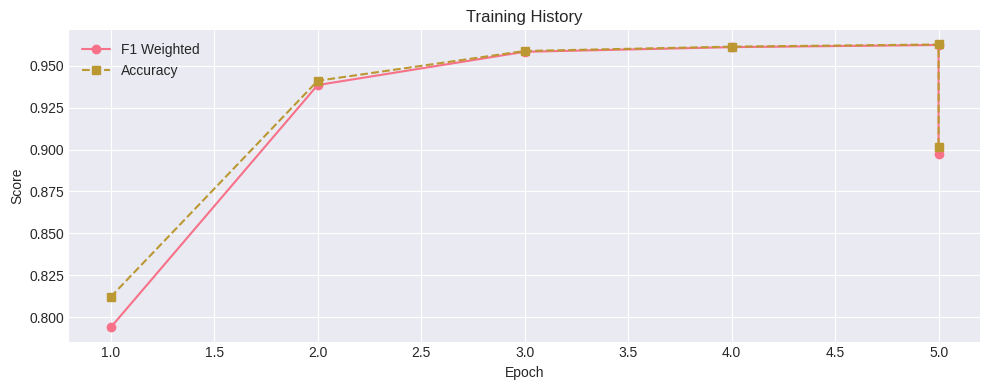

In [ ]:
history = [
    (e["epoch"], e.get("eval_f1_weighted"), e.get("eval_accuracy"))
    for e in trainer.state.log_history
    if "eval_f1_weighted" in e
]

if history:
    epochs, f1s, accs = zip(*history)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, f1s, "o-", label="F1 Weighted")
    ax.plot(epochs, accs, "s--", label="Accuracy")

    ax.set_title("Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
MAX_LEN_INTENT = 128
test_utterances = [
    "Can you please send me the updated project timeline by end of day?",
    "I will complete the API integration before next sprint.",
    "What was the budget allocated for Q3 marketing?",
    "The deployment failed due to a misconfigured environment variable.",
    "Let's schedule a follow-up meeting for Thursday at 2 PM.",
    "I need someone to review the security audit report.",
]

model.eval()

for utt in test_utterances:
    enc = tokenizer(
        utt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN_INTENT
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**enc).logits

    probs = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    confidence = probs[pred_id].item()

    print(f"Text: {utt}")
    print(f"Prediction: {id2label[pred_id]} \n")

Text: Can you please send me the updated project timeline by end of day?
Prediction: meeting_schedule 

Text: I will complete the API integration before next sprint.
Prediction: oos 

Text: What was the budget allocated for Q3 marketing?
Prediction: income 

Text: The deployment failed due to a misconfigured environment variable.
Prediction: account_blocked 

Text: Let's schedule a follow-up meeting for Thursday at 2 PM.
Prediction: schedule_meeting 

Text: I need someone to review the security audit report.
Prediction: vaccines 



### 1.7 Save Intent Model

In [ ]:
#  Save Model, Tokenizer & Config
import json

# Save trained model
trainer.save_model(str(MODEL_DIRS["intent"]))

# Save tokenizer
tokenizer.save_pretrained(str(MODEL_DIRS["intent"]))

# Save label mappings for inference
label_config = {
    "id2label": id2label,
    "label2id": label2id
}

with open(MODEL_DIRS["intent"] / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

print(f"Model saved to: {MODEL_DIRS['intent']}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: nlu_models/intent_classifier



# Module 2:Named Entity Recognition (NER)







### 2.1 Load & Explore CoNLL-2003

In [ ]:
#  Load CoNLL-2003
ds_ner_raw = load_dataset("eriktks/conll2003", trust_remote_code=True)
print(ds_ner_raw)
print("\n Features:", ds_ner_raw["train"].features)

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

 Features: {'id': Value(dtype='string', id=None), 'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'pos_tags': Sequence(feature=ClassLabel(names=['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB'], id=None), length=-1, id=None), 'chunk_tags': Sequence(feature=ClassLabel(names=['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP',

In [ ]:
# NER label mapping
ner_label_list = ds_ner_raw["train"].features["ner_tags"].feature.names
print(f"\n NER Labels ({len(ner_label_list)}): {ner_label_list}")



 NER Labels (9): ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


In [ ]:
# Sample
df_ner_sample = pd.DataFrame(ds_ner_raw["train"].select(range(5)))
display(df_ner_sample[["tokens", "ner_tags"]].head(3))

,tokens,ner_tags
0,"[EU, rejects, German, call, to, boycott, Briti...","[3, 0, 7, 0, 0, 0, 7, 0, 0]"
1,"[Peter, Blackburn]","[1, 2]"
2,"[BRUSSELS, 1996-08-22]","[5, 0]"


### 2.2 EDA

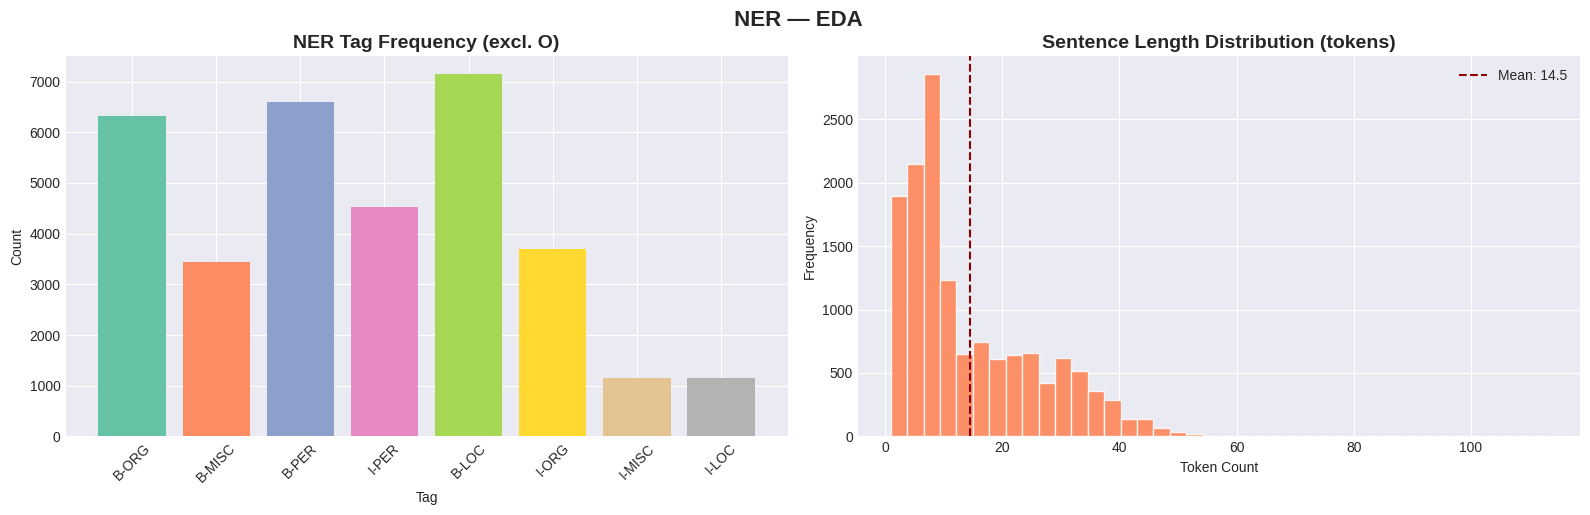

In [ ]:
df_ner_train = pd.DataFrame(ds_ner_raw["train"])

# Token count per sentence
df_ner_train["n_tokens"] = df_ner_train["tokens"].apply(len)

# Flatten tags to count label frequency
all_tags = [tag for tags in df_ner_train["ner_tags"] for tag in tags]
tag_counts = Counter(all_tags)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tag frequency (excluding O)
non_o_tags = {ner_label_list[k]: v for k, v in tag_counts.items() if ner_label_list[k] != "O"}
axes[0].bar(non_o_tags.keys(), non_o_tags.values(), color=sns.color_palette("Set2", len(non_o_tags)))
axes[0].set_title("NER Tag Frequency (excl. O)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Tag"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Sentence lengths
axes[1].hist(df_ner_train["n_tokens"], bins=40, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvline(df_ner_train["n_tokens"].mean(), color="darkred", linestyle="--",
                label=f'Mean: {df_ner_train["n_tokens"].mean():.1f}')
axes[1].set_title("Sentence Length Distribution (tokens)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Token Count"); axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.suptitle(" NER — EDA", fontsize=16, fontweight="bold", y=1.02)
plt.savefig(BASE_DIR / "ner_eda.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print(f"\nDataset Stats:")
print(f"  Train sentences: {len(df_ner_train):,}")
print(f"  Avg tokens/sentence: {df_ner_train['n_tokens'].mean():.1f}")
print(f"  Total tokens: {df_ner_train['n_tokens'].sum():,}")


Dataset Stats:
  Train sentences: 14,041
  Avg tokens/sentence: 14.5
  Total tokens: 203,621


### 2.3 Data Cleaning

In [ ]:
def clean_ner_split(dataset_split, max_len=128):
    df = pd.DataFrame(dataset_split)
    orig = len(df)
    # Remove empty sequences
    df = df[df["tokens"].apply(len) > 0].reset_index(drop=True)
    # Remove extremely long sequences
    df = df[df["tokens"].apply(len) <= max_len].reset_index(drop=True)
    # Remove sequences with mismatched tokens/tags
    df = df[df.apply(lambda r: len(r["tokens"]) == len(r["ner_tags"]), axis=1)].reset_index(drop=True)
    print(f"  {orig} → {len(df)} sequences (removed {orig - len(df)})")
    return Dataset.from_pandas(df[["tokens", "ner_tags", "pos_tags", "chunk_tags"]])

ds_ner_clean = DatasetDict({
    "train":      clean_ner_split(ds_ner_raw["train"]),
    "validation": clean_ner_split(ds_ner_raw["validation"]),
    "test":       clean_ner_split(ds_ner_raw["test"]),
})


  14041 → 14041 sequences (removed 0)
  3250 → 3250 sequences (removed 0)
  3453 → 3453 sequences (removed 0)


### 2.4 Tokenization + Label Alignment

In [ ]:
NER_MODEL_NAME = "bert-base-cased"
print(f" Loading tokenizer: {NER_MODEL_NAME}")
ner_tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_NAME)

MAX_LEN_NER = 128

def tokenize_and_align_labels(examples):
    tokenized_inputs = ner_tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=MAX_LEN_NER,
        is_split_into_words=True,
    )
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)          # special tokens → ignore
            elif word_id != prev_word_id:
                label_ids.append(label[word_id])  # first subword → real label
            else:
                label_ids.append(-100)           # subsequent subwords → ignore
            prev_word_id = word_id
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

ds_ner_tok = ds_ner_clean.map(
    tokenize_and_align_labels, batched=True,
    remove_columns=ds_ner_clean["train"].column_names,
    desc="Aligning NER labels"
)
ds_ner_tok.set_format("torch")


 Loading tokenizer: bert-base-cased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Aligning NER labels:   0%|          | 0/14041 [00:00<?, ? examples/s]

Aligning NER labels:   0%|          | 0/3250 [00:00<?, ? examples/s]

Aligning NER labels:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [ ]:
#  Load BERT + NER head
id2label_ner = {i: l for i, l in enumerate(ner_label_list)}
label2id_ner = {l: i for i, l in enumerate(ner_label_list)}

ner_model = AutoModelForTokenClassification.from_pretrained(
    NER_MODEL_NAME,
    num_labels=len(ner_label_list),
    id2label=id2label_ner,
    label2id=label2id_ner,
    ignore_mismatched_sizes=True,
)
ner_model.to(DEVICE)

total_ner = sum(p.numel() for p in ner_model.parameters())
print(f" Model: {NER_MODEL_NAME}")
print(f"   Total params: {total_ner:,}")
print(f"   NER labels:   {len(ner_label_list)}")


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

 Model: bert-base-cased
   Total params: 107,726,601
   NER labels:   9


In [ ]:
#  Seqeval Metric
seqeval_metric = evaluate.load("seqeval")

def compute_ner_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_preds = [
        [ner_label_list[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(preds, labels)
    ]

    true_labels = [
        [ner_label_list[l] for l in label if l != -100]
        for label in labels
    ]

    results = seqeval_metric.compute(
        predictions=true_preds,
        references=true_labels
    )

    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }


#  Training Arguments
ner_output_dir = str(MODEL_DIRS["ner"])

num_training_steps = (len(ds_ner_tok["train"]) // 32) * 5
warmup_steps = int(0.1 * num_training_steps)

ner_training_args = TrainingArguments(
    output_dir=ner_output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    weight_decay=0.01,

    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
)


#  Trainer
ner_trainer = Trainer(
    model=ner_model,
    args=ner_training_args,
    train_dataset=ds_ner_tok["train"],
    eval_dataset=ds_ner_tok["validation"],
    data_collator=DataCollatorForTokenClassification(ner_tokenizer),
    compute_metrics=compute_ner_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


#  Train
print(f"   Model:  {NER_MODEL_NAME}")
print(f"   Train:  {len(ds_ner_tok['train']):,} samples")
print(f"   Val:    {len(ds_ner_tok['validation']):,} samples")

ner_train_result = ner_trainer.train()

print(f"   Loss:        {ner_train_result.training_loss:.4f}")
print(f"   Runtime:     {ner_train_result.metrics['train_runtime']:.0f}s")

   Model:  bert-base-cased
   Train:  14,041 samples
   Val:    3,250 samples


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.054329,0.044666,0.916584,0.929245,0.922871,0.987082
2,0.029283,0.039886,0.936103,0.945249,0.940654,0.989927
3,0.014359,0.035664,0.941363,0.949292,0.945311,0.990842
4,0.008064,0.037484,0.946181,0.953673,0.949912,0.991563
5,0.004656,0.036790,0.944936,0.954009,0.949451,0.991602


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

   Loss:        0.0805
   Runtime:     372s


### 2.6 Testing & Evaluation — NER

 Evaluating NER on TEST set...



 NER Test Results:
   eval_loss: 0.1086
   eval_precision: 0.9072
   eval_recall: 0.9213
   eval_f1: 0.9142
   eval_accuracy: 0.9829
   eval_runtime: 4.5915
   eval_samples_per_second: 752.0360
   eval_steps_per_second: 11.7610
   epoch: 5.0000
   PER: P=0.964  R=0.960  F1=0.962  Support=1615
   ORG: P=0.886  R=0.909  F1=0.897  Support=1661
   LOC: P=0.935  R=0.932  F1=0.933  Support=1666
   MISC: P=0.773  R=0.836  F1=0.804  Support=702


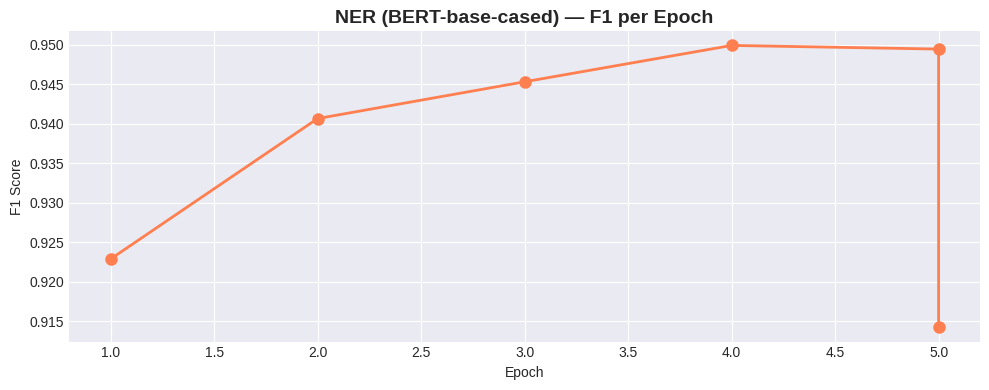

   'John Smith will present the Q3 report to Microsoft's board in New York on Friday.'
     [PER] 'John Smith' (score: 0.999)
     [MISC] 'Q' (score: 0.510)
     [ORG] 'Microsoft' (score: 0.999)
     [LOC] 'New York' (score: 0.999)

   'Sarah from Google mentioned that the AWS deployment in Frankfurt is complete.'
     [PER] 'Sarah' (score: 0.998)
     [ORG] 'Google' (score: 0.998)
     [MISC] 'AWS' (score: 0.557)
     [LOC] 'Frankfurt' (score: 0.999)

   'The budget approval from CFO James Lee is required before the IBM partnership proceeds.'
     [PER] 'James Lee' (score: 0.999)
     [ORG] 'IBM' (score: 0.999)



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 NER model saved to: nlu_models/ner_model


In [ ]:
#  Evaluate on Test Set
print(" Evaluating NER on TEST set...")
ner_test_results = ner_trainer.evaluate(ds_ner_tok["test"])
print("\n NER Test Results:")
for k, v in ner_test_results.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")

#  Per-Entity Results
ner_preds_out = ner_trainer.predict(ds_ner_tok["test"])
y_pred_ner = np.argmax(ner_preds_out.predictions, axis=-1)
y_true_ner = ner_preds_out.label_ids

true_preds_full = [
    [ner_label_list[p] for p, l in zip(pred, label) if l != -100]
    for pred, label in zip(y_pred_ner, y_true_ner)
]
true_labels_full = [
    [ner_label_list[l] for l in label if l != -100]
    for label in y_true_ner
]
detailed = seqeval_metric.compute(predictions=true_preds_full, references=true_labels_full)
for entity_type in ["PER", "ORG", "LOC", "MISC"]:
    if entity_type in detailed:
        ed = detailed[entity_type]
        print(f"   {entity_type}: P={ed['precision']:.3f}  R={ed['recall']:.3f}  F1={ed['f1']:.3f}  Support={ed['number']}")

#  Training History Plot
ner_history = [(e["epoch"], e["eval_f1"])
               for e in ner_trainer.state.log_history if "eval_f1" in e]
if ner_history:
    ep, f1 = zip(*ner_history)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ep, f1, "o-", color="coral", linewidth=2, markersize=8)
    ax.set_title("NER (BERT-base-cased) — F1 per Epoch", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("F1 Score"); ax.grid(True)
    plt.tight_layout()
    plt.savefig(BASE_DIR / "ner_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()

# Real-World Inference
from transformers import pipeline
ner_pipe = pipeline("ner", model=ner_model, tokenizer=ner_tokenizer,
                    aggregation_strategy="simple", device=0 if torch.cuda.is_available() else -1)

meeting_texts = [
    "John Smith will present the Q3 report to Microsoft's board in New York on Friday.",
    "Sarah from Google mentioned that the AWS deployment in Frankfurt is complete.",
    "The budget approval from CFO James Lee is required before the IBM partnership proceeds.",
]
for text in meeting_texts:
    entities = ner_pipe(text)
    print(f"   '{text}'")
    for ent in entities:
        print(f"     [{ent['entity_group']}] '{ent['word']}' (score: {ent['score']:.3f})")
    print()

# ─── Save Model ───────────────────────────────────────────────────────────
ner_trainer.save_model(str(MODEL_DIRS["ner"]))
ner_tokenizer.save_pretrained(str(MODEL_DIRS["ner"]))
print(f" NER model saved to: {MODEL_DIRS['ner']}")



#  Module 3: Dialogue Summarization



### 3.1 Load & Merge SAMSum + DialogSum

In [ ]:
#  Load both summarization datasets
print(" Loading SAMSum dataset")
ds_samsum = load_dataset("knkarthick/samsum", trust_remote_code=True)
print(ds_samsum)

print("\n Loading DialogSum dataset")
ds_dialogsum = load_dataset("knkarthick/dialogsum", trust_remote_code=True)
print(ds_dialogsum)

# Show samples
print("\n SAMSum sample:")
display(pd.DataFrame(ds_samsum["train"].select(range(2)))[["dialogue", "summary"]])
print("\n DialogSum sample:")
display(pd.DataFrame(ds_dialogsum["train"].select(range(2)))[["dialogue", "summary"]])


 Loading SAMSum dataset


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

 Loading DialogSum dataset


...

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})

 SAMSum sample:


,dialogue,summary
0,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...



 DialogSum sample:


,dialogue,summary
0,"#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. ...","Mr. Smith's getting a check-up, and Doctor Haw..."
1,"#Person1#: Hello Mrs. Parker, how have you bee...",Mrs Parker takes Ricky for his vaccines. Dr. P...


### 3.2 EDA — Summarization

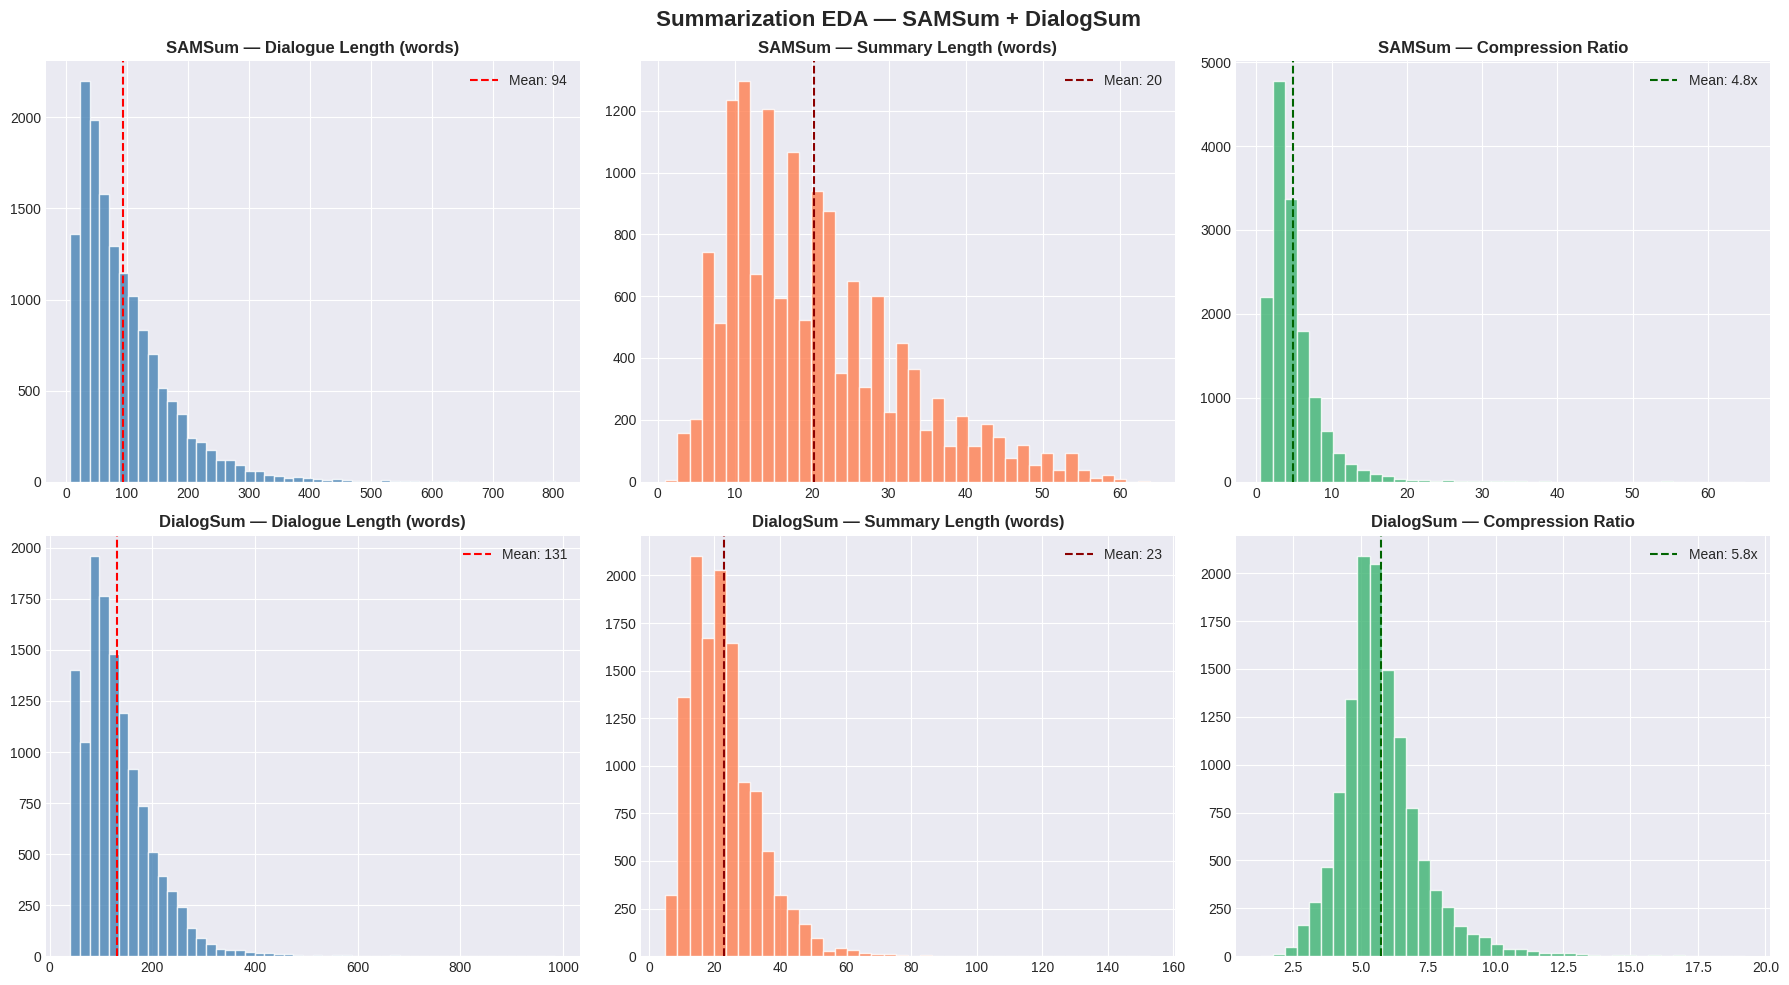

SAMSum: 14,731 train samples | avg dialogue: 94 words
DialogSum: 12,460 train samples | avg dialogue: 131 words


In [ ]:
df_sam = pd.DataFrame(ds_samsum["train"])
df_dia = pd.DataFrame(ds_dialogsum["train"])

# Compute lengths
df_sam["dialogue_len"] = df_sam["dialogue"].str.split().str.len()
df_sam["summary_len"]  = df_sam["summary"].str.split().str.len()
df_sam["compression"]  = df_sam["dialogue_len"] / df_sam["summary_len"].clip(lower=1)

df_dia["dialogue_len"] = df_dia["dialogue"].str.split().str.len()
df_dia["summary_len"]  = df_dia["summary"].str.split().str.len()
df_dia["compression"]  = df_dia["dialogue_len"] / df_dia["summary_len"].clip(lower=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (df, name) in enumerate([(df_sam, "SAMSum"), (df_dia, "DialogSum")]):
    axes[row][0].hist(df["dialogue_len"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
    axes[row][0].set_title(f"{name} — Dialogue Length (words)", fontweight="bold")
    axes[row][0].axvline(df["dialogue_len"].mean(), color="red", linestyle="--",
                         label=f"Mean: {df['dialogue_len'].mean():.0f}")
    axes[row][0].legend()

    axes[row][1].hist(df["summary_len"], bins=40, color="coral", alpha=0.8, edgecolor="white")
    axes[row][1].set_title(f"{name} — Summary Length (words)", fontweight="bold")
    axes[row][1].axvline(df["summary_len"].mean(), color="darkred", linestyle="--",
                         label=f"Mean: {df['summary_len'].mean():.0f}")
    axes[row][1].legend()

    axes[row][2].hist(df["compression"], bins=40, color="mediumseagreen", alpha=0.8, edgecolor="white")
    axes[row][2].set_title(f"{name} — Compression Ratio", fontweight="bold")
    axes[row][2].axvline(df["compression"].mean(), color="darkgreen", linestyle="--",
                         label=f"Mean: {df['compression'].mean():.1f}x")
    axes[row][2].legend()

plt.suptitle(" Summarization EDA — SAMSum + DialogSum", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR / "summarization_eda.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"SAMSum: {len(df_sam):,} train samples | avg dialogue: {df_sam['dialogue_len'].mean():.0f} words")
print(f"DialogSum: {len(df_dia):,} train samples | avg dialogue: {df_dia['dialogue_len'].mean():.0f} words")


### 3.3 Data Cleaning & Merging

In [ ]:
#  Data Cleaning & Merge
def clean_summ_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\n+", " \n ", text).strip()
    text = re.sub(r" +", " ", text)
    return text

def clean_summ_split(dataset_split, max_diag_words=800, max_summ_words=150):
    df = pd.DataFrame(dataset_split)[["dialogue", "summary"]]
    orig = len(df)
    df["dialogue"] = df["dialogue"].apply(clean_summ_text)
    df["summary"]  = df["summary"].apply(clean_summ_text)
    df = df[df["dialogue"].str.len() > 10].reset_index(drop=True)
    df = df[df["summary"].str.len() > 5].reset_index(drop=True)
    df["dw"] = df["dialogue"].str.split().str.len()
    df["sw"] = df["summary"].str.split().str.len()
    df = df[(df["dw"] <= max_diag_words) & (df["sw"] <= max_summ_words)].reset_index(drop=True)
    df = df.drop(columns=["dw", "sw"])
    print(f"  {orig} → {len(df)} samples")
    return Dataset.from_pandas(df)

sam_train   = clean_summ_split(ds_samsum["train"])
sam_val     = clean_summ_split(ds_samsum["validation"])
sam_test    = clean_summ_split(ds_samsum["test"])

dia_train   = clean_summ_split(ds_dialogsum["train"])
dia_val     = clean_summ_split(ds_dialogsum["validation"])
dia_test    = clean_summ_split(ds_dialogsum["test"])

from datasets import concatenate_datasets

ds_summ = DatasetDict({
    "train":      concatenate_datasets([sam_train, dia_train]),
    "validation": concatenate_datasets([sam_val,   dia_val]),
    "test":       concatenate_datasets([sam_test,  dia_test]),
})

  14731 → 14728 samples
  818 → 818 samples
  819 → 819 samples
  12460 → 12458 samples
  500 → 500 samples
  1500 → 1500 samples


### 3.4 Tokenization + Fine-Tuning BART-base

In [ ]:
#  BART Tokenizer
from transformers import AutoTokenizer

SUMM_MODEL_NAME = "facebook/bart-base"
print(f" Loading tokenizer: {SUMM_MODEL_NAME}")

summ_tokenizer = AutoTokenizer.from_pretrained(SUMM_MODEL_NAME, use_fast=True)

MAX_SRC = 512
MAX_TGT = 128


def tokenize_summ(examples):
    # Encode inputs (dialogue)
    model_inputs = summ_tokenizer(
        examples["dialogue"],
        max_length=MAX_SRC,
        truncation=True,
        padding="max_length"
    )

    labels = summ_tokenizer(
        text_target=examples["summary"],
        max_length=MAX_TGT,
        truncation=True,
        padding="max_length"
    )

    labels["input_ids"] = [
        [(token if token != summ_tokenizer.pad_token_id else -100) for token in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs



ds_summ_tok = ds_summ.map(
    tokenize_summ,
    batched=True,
    remove_columns=["dialogue", "summary"],
    desc="Tokenizing for BART"
)

ds_summ_tok.set_format("torch")

 Loading tokenizer: facebook/bart-base


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing for BART:   0%|          | 0/27186 [00:00<?, ? examples/s]

Tokenizing for BART:   0%|          | 0/1318 [00:00<?, ? examples/s]

Tokenizing for BART:   0%|          | 0/2319 [00:00<?, ? examples/s]

In [ ]:
#  BART Model

import torch
import numpy as np
import evaluate

from transformers import (
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)

rouge = evaluate.load("rouge")


#  Model
summ_model = AutoModelForSeq2SeqLM.from_pretrained(SUMM_MODEL_NAME)
summ_model.to(DEVICE)

total_summ = sum(p.numel() for p in summ_model.parameters())
print(f"{SUMM_MODEL_NAME} — {total_summ:,} params")


#  Output Dir
summ_output_dir = str(MODEL_DIRS["summarizer"])


#  Reduce Dataset Size
ds_summ_tok["train"] = ds_summ_tok["train"].shuffle(seed=42).select(range(13000))
ds_summ_tok["validation"] = ds_summ_tok["validation"].shuffle(seed=42).select(range(1000))


#  Training setup
num_training_steps = (len(ds_summ_tok["train"]) // 8) * 3
warmup_steps = int(0.1 * num_training_steps)


#  Training Arguments
summ_training_args = TrainingArguments(
    output_dir=summ_output_dir,

    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=2,

    learning_rate=5e-5,
    weight_decay=0.01,

    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",

    eval_strategy="steps",
    eval_steps=1000,

    save_strategy="steps",
    save_steps=1000,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_steps=100,
    fp16=torch.cuda.is_available(),

    report_to="none",
    seed=42,

    prediction_loss_only=True
)


#  Trainer
summ_trainer = Trainer(
    model=summ_model,
    args=summ_training_args,

    train_dataset=ds_summ_tok["train"],
    eval_dataset=ds_summ_tok["validation"],

    data_collator=DataCollatorForSeq2Seq(
        summ_tokenizer,
        model=summ_model,
        pad_to_multiple_of=8
    ),

    compute_metrics=None,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


#  Train
print(f"Train: {len(ds_summ_tok['train']):,} | Val: {len(ds_summ_tok['validation']):,}")

summ_train_result = summ_trainer.train()


#  Results
print(f"Loss: {summ_train_result.training_loss:.4f}")
print(f"Runtime: {summ_train_result.metrics['train_runtime']:.0f}s")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

facebook/bart-base — 139,420,416 params
Train: 13,000 | Val: 1,000


Step,Training Loss,Validation Loss
1000,1.658732,1.522954
2000,1.406501,1.454589
3000,1.352073,1.421651
4000,1.148363,1.400591


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Loss: 1.4306
Runtime: 1513s


### 3.5 Testing & Evaluation — Summarization

In [ ]:
#  Test Set Evaluation
print("Evaluating BART on TEST set...")

summ_test_results = summ_trainer.evaluate(ds_summ_tok["test"])

print("\nSummarization Test Results:")
for k, v in summ_test_results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")


rouge_hist = [
    (e["epoch"], e.get("eval_rouge1"), e.get("eval_rouge2"), e.get("eval_rougeL"))
    for e in summ_trainer.state.log_history
    if "eval_rouge1" in e
]

if rouge_hist:
    import matplotlib.pyplot as plt

    ep, r1, r2, rL = zip(*rouge_hist)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ep, r1, "o-", label="ROUGE-1", linewidth=2)
    ax.plot(ep, r2, "s--", label="ROUGE-2", linewidth=2)
    ax.plot(ep, rL, "^:", label="ROUGE-L", linewidth=2)

    ax.set_title("BART Summarization — ROUGE Scores per Epoch", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("ROUGE Score")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(BASE_DIR / "summ_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("ROUGE history not available (metrics disabled during training)")



def summarize(text):
    inputs = summ_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(DEVICE)

    outputs = summ_model.generate(
        **inputs,
        max_length=80,
        min_length=20,
        num_beams=4,
        early_stopping=True
    )

    return summ_tokenizer.decode(outputs[0], skip_special_tokens=True)


meeting_dialogues = [
    """
    Alice: Morning team! Let's kick off our sprint review. John, can you walk us through the backend progress?
    John: Sure. We've completed the user authentication API and the database migration. There were some delays with the payment gateway integration due to a third-party API issue.
    Alice: Got it. Sarah, what's the status on the frontend?
    Sarah: The dashboard and profile pages are done. The notifications module is 80% complete, should be ready by Thursday.
    Alice: Great. Any blockers?
    John: We need the design specs for the admin panel before we can start that.
    Sarah: I'll follow up with the design team today.
    Alice: Perfect. Let's schedule a follow-up on Friday to review the payment gateway fix. Mark it as high priority.
    """
]

for dialogue in meeting_dialogues:
    summary = summarize(dialogue.strip())

    print(f"\nOriginal ({len(dialogue.split())} words):")
    print(f"{dialogue.strip()[:200]}...")

    print(f"\nSummary: {summary}")
    print()


#  Save Model
summ_trainer.save_model(str(MODEL_DIRS["summarizer"]))
summ_tokenizer.save_pretrained(str(MODEL_DIRS["summarizer"]))

print(f"Summarization model saved to: {MODEL_DIRS['summarizer']}")

Evaluating BART on TEST set...



Summarization Test Results:
eval_loss: 1.4697
eval_runtime: 27.0304
eval_samples_per_second: 85.7920
eval_steps_per_second: 42.9150
epoch: 3.0000
ROUGE history not available (metrics disabled during training)

Original (121 words):
Alice: Morning team! Let's kick off our sprint review. John, can you walk us through the backend progress?
    John: Sure. We've completed the user authentication API and the database migration. There...

Summary: Alice, John and Sarah are going to kick off their sprint review. John has completed the user authentication API and the database migration. Sarah will follow up with the design team on Friday to review the payment gateway fix.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Summarization model saved to: nlu_models/summarizer



#  Module 4: Action Item Extraction


### 4.1 Load & Explore QMSum

In [ ]:
# Load QMSum
from datasets import load_dataset


ds_qmsum_raw = load_dataset("pszemraj/qmsum-cleaned")

print(ds_qmsum_raw)

print("\nFeatures:", ds_qmsum_raw["train"].features)

print("\nSample:")

sample_qm = ds_qmsum_raw["train"][0]

print("Keys:", list(sample_qm.keys()))

for k, v in sample_qm.items():
    print(f"{k}: {str(v)[:150]}")

Generating train split:   0%|          | 0/1257 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/272 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/281 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'pid', 'input', 'output', 'input_token_count', 'output_token_count'],
        num_rows: 1257
    })
    validation: Dataset({
        features: ['id', 'pid', 'input', 'output', 'input_token_count', 'output_token_count'],
        num_rows: 272
    })
    test: Dataset({
        features: ['id', 'pid', 'input', 'output', 'input_token_count', 'output_token_count'],
        num_rows: 281
    })
})

Features: {'id': Value(dtype='string', id=None), 'pid': Value(dtype='string', id=None), 'input': Value(dtype='string', id=None), 'output': Value(dtype='string', id=None), 'input_token_count': Value(dtype='int64', id=None), 'output_token_count': Value(dtype='int64', id=None)}

Sample:
Keys: ['id', 'pid', 'input', 'output', 'input_token_count', 'output_token_count']
id: tr-sq-1
pid: tr-sq-1_0
input: How Did Project Manager and User Interface introduce the prototype of the remote control?
Project Manager: Yep. Soon as I get this. Okay. Thi

### 4.2 EDA — Action Extraction

Columns: ['id', 'pid', 'input', 'output', 'input_token_count', 'output_token_count']
id                    object
pid                   object
input                 object
output                object
input_token_count      int64
output_token_count     int64
dtype: object
Train samples: 1,257

Using text_col='input', summ_col='output'


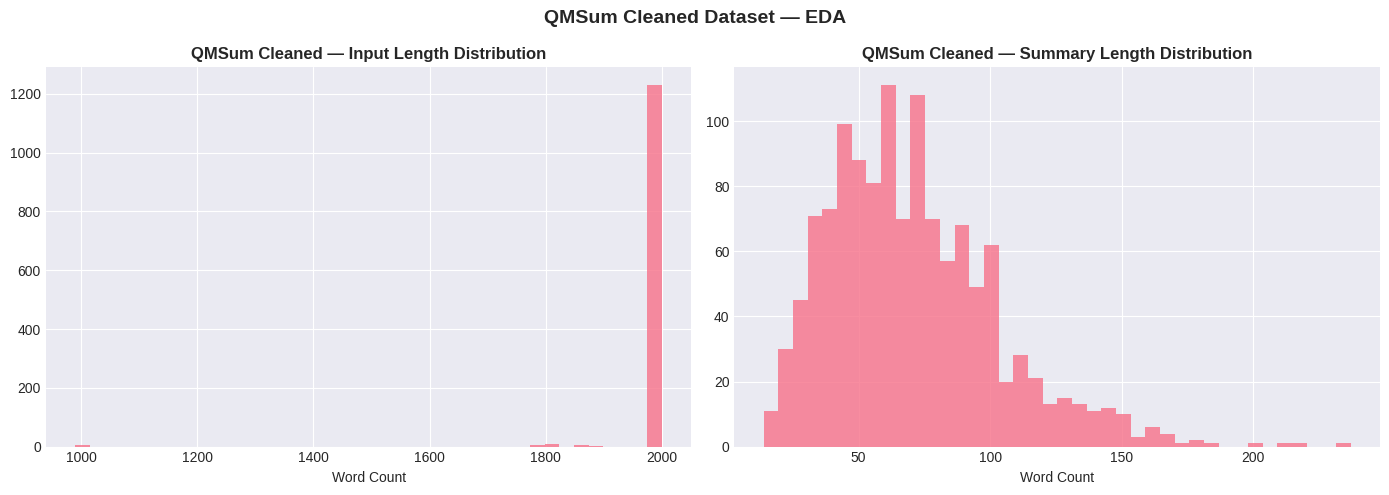


Avg input words:  9319
Avg output words: 71


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

train_ds = ds_qmsum_raw["train"]

# Convert to DataFrame
df_qm = pd.DataFrame(train_ds)

print("Columns:", df_qm.columns.tolist())
print(df_qm.dtypes)
print(f"Train samples: {len(df_qm):,}")

# --- Columns ---
text_col = "input"
summ_col = "output"

print(f"\nUsing text_col='{text_col}', summ_col='{summ_col}'")

assert text_col in df_qm.columns, f"{text_col} not found!"
assert summ_col in df_qm.columns, f"{summ_col} not found!"

# Length features (word-based)
df_qm["input_len"] = df_qm[text_col].fillna("").astype(str).str.split().str.len()
df_qm["output_len"] = df_qm[summ_col].fillna("").astype(str).str.split().str.len()

# Clip extreme values for visualization
input_clip = df_qm["input_len"].clip(upper=2000)
output_clip = df_qm["output_len"].clip(upper=300)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(input_clip, bins=40, alpha=0.8)
axes[0].set_title("QMSum Cleaned — Input Length Distribution", fontweight="bold")
axes[0].set_xlabel("Word Count")

axes[1].hist(output_clip, bins=40, alpha=0.8)
axes[1].set_title("QMSum Cleaned — Summary Length Distribution", fontweight="bold")
axes[1].set_xlabel("Word Count")

plt.suptitle("QMSum Cleaned Dataset — EDA", fontsize=14, fontweight="bold")

plt.tight_layout()

# Save figure
BASE_DIR = Path(".")
plt.savefig(BASE_DIR / "qmsum_cleaned_eda.png", dpi=150, bbox_inches="tight")

plt.show()

# Stats
print(f"\nAvg input words:  {df_qm['input_len'].mean():.0f}")
print(f"Avg output words: {df_qm['output_len'].mean():.0f}")

### 4.3 Data Cleaning & Preprocessing

In [ ]:
from datasets import Dataset, DatasetDict
import pandas as pd


def make_action_prompt(meeting_text):
    return (
        "You are an AI assistant specialized in analyzing meetings.\n"
        "Extract all action items, tasks, and commitments clearly as bullet points.\n\n"
        "Meeting Transcript:\n"
        + str(meeting_text)[:3000]
    )


# Cleaning function
def clean_qmsum_split(dataset_split, max_samples=3000):
    df = pd.DataFrame(dataset_split)

    # Fixed columns for new dataset
    text_col = "input"
    summ_col = "output"

    # Keep only needed columns safely
    df = df[[text_col, summ_col]].copy()
    df.columns = ["input", "output"]

    # Clean text
    df["input"] = df["input"].astype(str).str.strip()
    df["output"] = df["output"].astype(str).str.strip()

    # Remove bad samples
    df = df[
        (df["input"].str.len() > 20) &
        (df["output"].str.len() > 5)
    ].reset_index(drop=True)

    # Apply prompt ONLY on input
    df["input"] = df["input"].apply(make_action_prompt)

    # Sampling for speed
    if len(df) > max_samples:
        df = df.sample(max_samples, random_state=42).reset_index(drop=True)

    print(f"→ Final samples: {len(df)}")

    return Dataset.from_pandas(df)


# Dataset split

print("Loading dataset splits...")

train_ds = ds_qmsum_raw["train"]
val_ds   = ds_qmsum_raw["validation"]
test_ds  = ds_qmsum_raw["test"]



# Build final dataset

ds_action = DatasetDict({
    "train": clean_qmsum_split(train_ds, max_samples=3000),
    "validation": clean_qmsum_split(val_ds, max_samples=500),
    "test": clean_qmsum_split(test_ds, max_samples=500),
})

print(ds_action)

Loading dataset splits...
→ Final samples: 1257
→ Final samples: 272
→ Final samples: 0
DatasetDict({
    train: Dataset({
        features: ['input', 'output'],
        num_rows: 1257
    })
    validation: Dataset({
        features: ['input', 'output'],
        num_rows: 272
    })
    test: Dataset({
        features: ['input', 'output'],
        num_rows: 0
    })
})


### 4.4 Fine-Tuning Flan-T5-base

In [ ]:
import torch
import numpy as np
import evaluate

from transformers import (
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)

#  ROUGE
rouge = evaluate.load("rouge")

#  Model
summ_model = AutoModelForSeq2SeqLM.from_pretrained(SUMM_MODEL_NAME)
summ_model.to(DEVICE)

total_summ = sum(p.numel() for p in summ_model.parameters())
print(f"{SUMM_MODEL_NAME} — {total_summ:,} params")

summ_output_dir = str(MODEL_DIRS["summarizer"])


print(f"Train: {len(ds_summ_tok['train']):,} | Val: {len(ds_summ_tok['validation']):,}")


effective_batch    = 4 * 2
steps_per_epoch    = len(ds_summ_tok["train"]) // effective_batch
num_training_steps = steps_per_epoch * 3
warmup_steps       = max(10, int(0.1 * num_training_steps))
eval_interval      = max(50, steps_per_epoch // 2)

print(f"Steps/epoch: {steps_per_epoch} | Total steps: {num_training_steps}")
print(f"Eval every : {eval_interval} steps | Warmup: {warmup_steps} steps")

summ_training_args = TrainingArguments(
    output_dir=summ_output_dir,

    num_train_epochs=3,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=2,

    learning_rate=5e-5,
    weight_decay=0.01,

    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",

    eval_strategy="steps",
    eval_steps=eval_interval,

    save_strategy="steps",
    save_steps=eval_interval,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_steps=max(10, eval_interval // 3),

    fp16=torch.cuda.is_available(),
    bf16=False,

    report_to="none",
    seed=42,

    prediction_loss_only=True,
)

#  Trainer
summ_trainer = Trainer(
    model=summ_model,
    args=summ_training_args,

    train_dataset=ds_summ_tok["train"],
    eval_dataset=ds_summ_tok["validation"],

    processing_class=summ_tokenizer,

    data_collator=DataCollatorForSeq2Seq(
        summ_tokenizer,
        model=summ_model,
        pad_to_multiple_of=8
    ),

    compute_metrics=None,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

#  Train
summ_train_result = summ_trainer.train()

#  Results
print(f"\nLoss   : {summ_train_result.training_loss:.4f}")
print(f"Runtime: {summ_train_result.metrics['train_runtime']:.0f}s")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

facebook/bart-base — 139,420,416 params
Train: 13,000 | Val: 1,000
Steps/epoch: 1625 | Total steps: 4875
Eval every : 812 steps | Warmup: 487 steps


Step,Training Loss,Validation Loss
812,3.434686,1.535263
1624,3.250687,1.482739
2436,2.735166,1.449245
3248,2.653687,1.401902
4060,2.290103,1.413362
4872,2.239191,1.402157


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



Loss   : 2.8533
Runtime: 1812s


### 4.5 Testing & Evaluation — Action Extraction

In [ ]:
# Save action model
summ_model.save_pretrained(str(MODEL_DIRS["action"]))
summ_tokenizer.save_pretrained(str(MODEL_DIRS["action"]))
print(f"Action model saved to: {MODEL_DIRS['action']}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Action model saved to: nlu_models/action_extractor



# Module 5: Sentence Embeddings


### 5.1 Load & Explore STSB

In [ ]:
#  Load STSB
print(" Loading STSB dataset")
ds_stsb_raw = load_dataset("sentence-transformers/stsb", trust_remote_code=True)
print(ds_stsb_raw)


print("\n Features:", ds_stsb_raw["train"].features)

print("\nSample:")
display(pd.DataFrame(ds_stsb_raw["train"].select(range(5))))


 Loading STSB dataset


Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'score'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'score'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'score'],
        num_rows: 1379
    })
})

 Features: {'sentence1': Value(dtype='string', id=None), 'sentence2': Value(dtype='string', id=None), 'score': Value(dtype='float64', id=None)}

Sample:


,sentence1,sentence2,score
0,A plane is taking off.,An air plane is taking off.,1.00
1,A man is playing a large flute.,A man is playing a flute.,0.76
2,A man is spreading shreded cheese on a pizza.,A man is spreading shredded cheese on an uncoo...,0.76
3,Three men are playing chess.,Two men are playing chess.,0.52
4,A man is playing the cello.,A man seated is playing the cello.,0.85


### 5.2 EDA — STSB

Columns: ['sentence1', 'sentence2', 'score']
Train samples: 5,749
Score col: 'score', Sent1: 'sentence1', Sent2: 'sentence2'


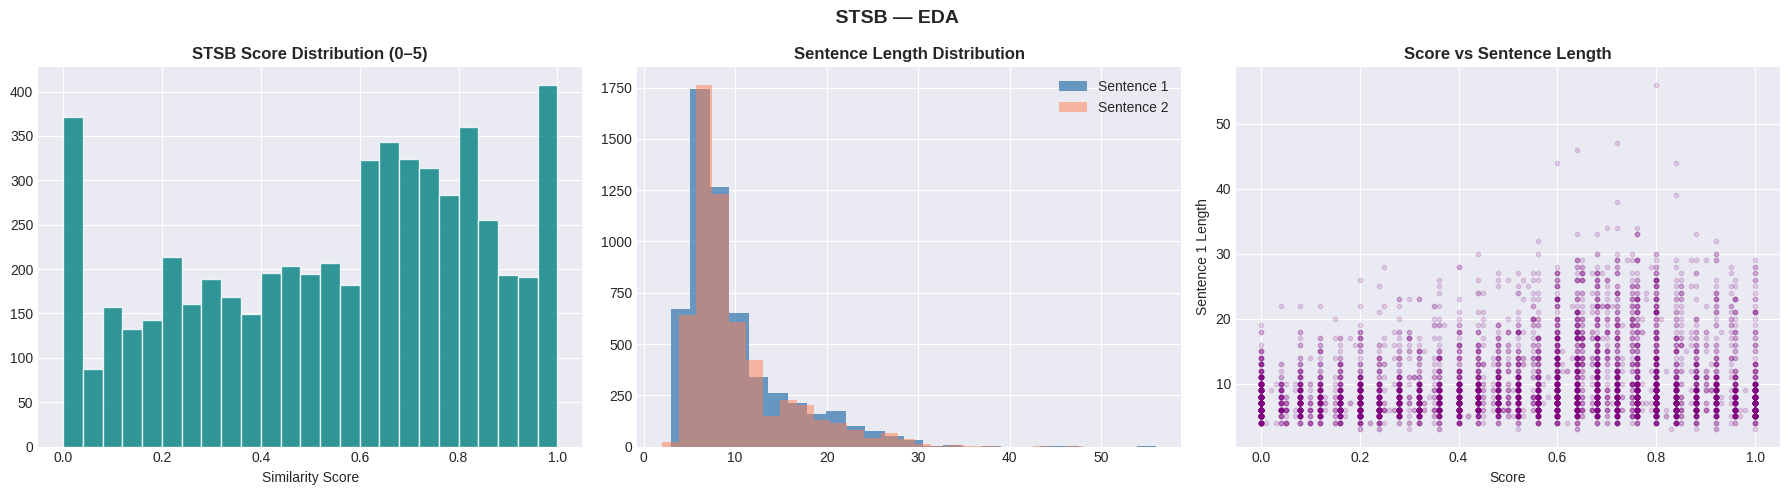

In [ ]:
df_stsb = pd.DataFrame(ds_stsb_raw["train"])
print(f"Columns: {df_stsb.columns.tolist()}")
print(f"Train samples: {len(df_stsb):,}")

# Score column name
score_col = "score" if "score" in df_stsb.columns else "label"
sent1_col = "sentence1" if "sentence1" in df_stsb.columns else df_stsb.columns[0]
sent2_col = "sentence2" if "sentence2" in df_stsb.columns else df_stsb.columns[1]
print(f"Score col: '{score_col}', Sent1: '{sent1_col}', Sent2: '{sent2_col}'")

df_stsb["s1_len"] = df_stsb[sent1_col].str.split().str.len()
df_stsb["s2_len"] = df_stsb[sent2_col].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_stsb[score_col], bins=25, color="teal", alpha=0.8, edgecolor="white")
axes[0].set_title("STSB Score Distribution (0–5)", fontweight="bold")
axes[0].set_xlabel("Similarity Score")

axes[1].hist(df_stsb["s1_len"], bins=25, color="steelblue", alpha=0.8, label="Sentence 1")
axes[1].hist(df_stsb["s2_len"], bins=25, color="coral", alpha=0.5, label="Sentence 2")
axes[1].set_title("Sentence Length Distribution", fontweight="bold")
axes[1].legend()

axes[2].scatter(df_stsb[score_col], df_stsb["s1_len"], alpha=0.15, s=10, color="purple")
axes[2].set_title("Score vs Sentence Length", fontweight="bold")
axes[2].set_xlabel("Score"); axes[2].set_ylabel("Sentence 1 Length")

plt.suptitle(" STSB — EDA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR / "stsb_eda.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Fine-Tuning with Cosine Similarity Loss

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers>=2.6.0"])

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader as TorchDataLoader

EMBED_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
print(f" Loading {EMBED_MODEL_NAME}...")
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=str(DEVICE))

#  Prepare InputExamples
def make_input_examples(dataset_split, sent1_col, sent2_col, score_col, max_samples=5000):
    df = pd.DataFrame(dataset_split)
    if len(df) > max_samples:
        df = df.sample(max_samples, random_state=42)
    examples = []
    for _, row in df.iterrows():
        score_normalized = float(row[score_col]) / 5.0  # normalize to [0, 1]
        examples.append(InputExample(
            texts=[str(row[sent1_col]), str(row[sent2_col])],
            label=score_normalized
        ))
    return examples

train_examples = make_input_examples(ds_stsb_raw["train"],      sent1_col, sent2_col, score_col, max_samples=5000)
val_examples   = make_input_examples(ds_stsb_raw["validation"], sent1_col, sent2_col, score_col, max_samples=500)
test_examples  = make_input_examples(ds_stsb_raw["test"],       sent1_col, sent2_col, score_col, max_samples=500)

print(f"Train: {len(train_examples):,} | Val: {len(val_examples):,} | Test: {len(test_examples):,}")

#  DataLoader + Loss
train_dataloader_emb = TorchDataLoader(train_examples, shuffle=True, batch_size=32)
train_loss = losses.CosineSimilarityLoss(embed_model)

#  Evaluator
val_evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name="stsb-val"
)

#  Fine-Tuning
embed_output_dir = str(MODEL_DIRS["embedding"])
embed_model.fit(
    train_objectives=[(train_dataloader_emb, train_loss)],
    evaluator=val_evaluator,
    epochs=3,
    evaluation_steps=500,
    warmup_steps=int(0.1 * len(train_dataloader_emb) * 4),
    output_path=embed_output_dir,
    save_best_model=True,
    show_progress_bar=True,
    use_amp=torch.cuda.is_available(),
    scheduler="warmupcosine",
    optimizer_params={"lr": 2e-5},
)

 Loading sentence-transformers/all-mpnet-base-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Stsb-val Pearson Cosine,Stsb-val Spearman Cosine
157,No log,No log,0.486637,0.480696
314,No log,No log,0.556214,0.563378
471,No log,No log,0.573431,0.580082


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### 5.4 Testing & Evaluation — Embeddings

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


STSB Test Evaluation:
  stsb-test_pearson_cosine: 0.4605
  stsb-test_spearman_cosine: 0.4639

Real-World Semantic Similarity in Meetings:


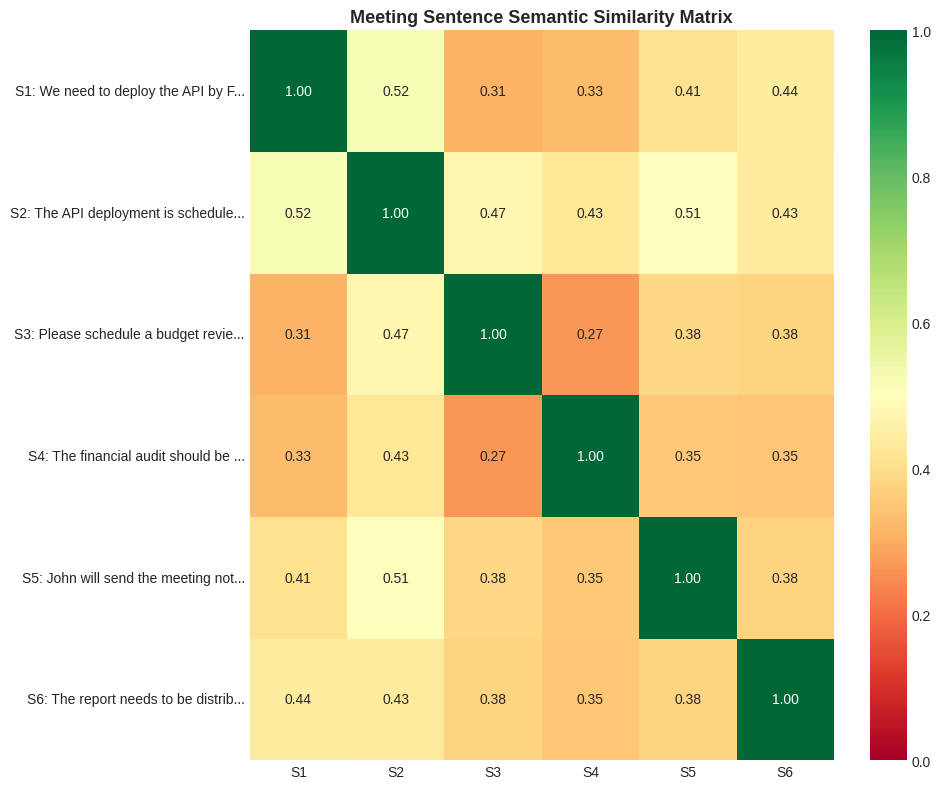

  S1: We need to deploy the API by Friday.
  S2: The API deployment is scheduled for end of week.
  S3: Please schedule a budget review meeting.
  S4: The financial audit should be completed before Q4.
  S5: John will send the meeting notes to everyone.
  S6: The report needs to be distributed to all stakeholders.

  Sim(S1, S2) = 0.520
  Sim(S1, S3) = 0.310
  Sim(S1, S4) = 0.327
  Sim(S1, S5) = 0.409
  Sim(S1, S6) = 0.438
  Sim(S2, S3) = 0.470
  Sim(S2, S4) = 0.426
  Sim(S2, S5) = 0.508
  Sim(S2, S6) = 0.435
  Sim(S3, S4) = 0.265
  Sim(S3, S5) = 0.383
  Sim(S3, S6) = 0.378
  Sim(S4, S5) = 0.354
  Sim(S4, S6) = 0.347
  Sim(S5, S6) = 0.375

Embedding model saved to: nlu_models/sentence_embedder


In [ ]:
#  Test Set Evaluation
embed_model_best = SentenceTransformer(str(MODEL_DIRS["embedding"]))

test_evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    test_examples, name="stsb-test"
)
test_score = test_evaluator(embed_model_best)

print("\nSTSB Test Evaluation:")
if isinstance(test_score, dict):
    for k, v in test_score.items():
        print(f"  {k}: {v:.4f}")
else:
    print(f"  Spearman Correlation: {test_score:.4f}")

print("\nReal-World Semantic Similarity in Meetings:")
from sklearn.metrics.pairwise import cosine_similarity

meeting_sentences = [
    "We need to deploy the API by Friday.",
    "The API deployment is scheduled for end of week.",
    "Please schedule a budget review meeting.",
    "The financial audit should be completed before Q4.",
    "John will send the meeting notes to everyone.",
    "The report needs to be distributed to all stakeholders.",
]

embeddings  = embed_model_best.encode(meeting_sentences, normalize_embeddings=True)
sim_matrix  = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    annot=True, fmt=".2f", cmap="RdYlGn",
    xticklabels=[f"S{i+1}" for i in range(len(meeting_sentences))],
    yticklabels=[f"S{i+1}: {s[:30]}..." for i, s in enumerate(meeting_sentences)],
    ax=ax, vmin=0, vmax=1
)
ax.set_title("Meeting Sentence Semantic Similarity Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR / "embedding_similarity_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

for i, s in enumerate(meeting_sentences):
    print(f"  S{i+1}: {s}")
print()
for i in range(len(meeting_sentences)):
    for j in range(i + 1, len(meeting_sentences)):
        print(f"  Sim(S{i+1}, S{j+1}) = {sim_matrix[i][j]:.3f}")

print(f"\nEmbedding model saved to: {MODEL_DIRS['embedding']}")

#  Module 6: Speech-to-Text (ASR)



### 6.1 Load & Explore AMI Corpus

In [ ]:
#  Load AMI Dataset
ds_ami_raw = load_dataset("edinburghcstr/ami", "ihm", trust_remote_code=True,
                          split="train[:5%]+validation[:20%]+test[:20%]")
print(f"Loaded {len(ds_ami_raw):,} AMI samples")
print("Features:", ds_ami_raw.features)
print("\nSample:")
sample_ami = ds_ami_raw[0]
for k in ["meeting_id", "text", "file"]:
    if k in sample_ami:
        val = sample_ami[k]
        print(f"  {k}: {str(val)[:100]}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

train: saved 10000 samples
validation: saved 1500 samples
test: saved 500 samples


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train:      10,000 samples
Validation: 1,500 samples
Test:       500 samples


### 6.2 EDA — ASR

Total samples: 12,000
Columns: ['meeting_id', 'audio_id', 'text', 'begin_time', 'end_time', 'microphone_id', 'speaker_id']


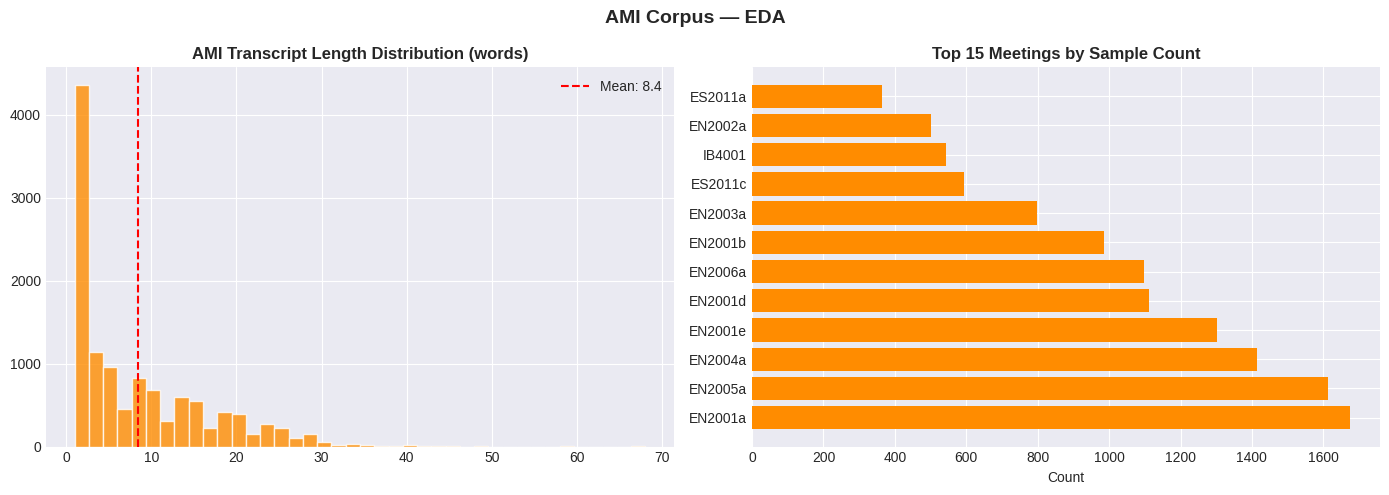


Avg words per utterance: 8.4


In [ ]:
df_ami = ds_ami_raw.to_pandas()
print(f"Total samples: {len(df_ami):,}")
print(f"Columns: {df_ami.columns.tolist()}")

text_col_ami = "text" if "text" in df_ami.columns else df_ami.columns[-1]
df_ami["text_len"] = df_ami[text_col_ami].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_ami["text_len"], bins=40, color="darkorange", alpha=0.8, edgecolor="white")
axes[0].set_title("AMI Transcript Length Distribution (words)", fontweight="bold")
axes[0].axvline(df_ami["text_len"].mean(), color="red", linestyle="--",
                label=f"Mean: {df_ami['text_len'].mean():.1f}")
axes[0].legend()

if "meeting_id" in df_ami.columns:
    meeting_counts = df_ami["meeting_id"].value_counts().head(15)
    axes[1].barh(meeting_counts.index, meeting_counts.values, color="darkorange")
    axes[1].set_title("Top 15 Meetings by Sample Count", fontweight="bold")
    axes[1].set_xlabel("Count")

plt.suptitle(" AMI Corpus — EDA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR / "ami_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nAvg words per utterance: {df_ami['text_len'].mean():.1f}")


### 6.3 Fine-Tuning Whisper

In [ ]:
from transformers import (
    WhisperProcessor, WhisperForConditionalGeneration,
    WhisperFeatureExtractor, WhisperTokenizer,
    Seq2SeqTrainingArguments, Seq2SeqTrainer,
)
import librosa

STT_MODEL_NAME = "openai/whisper-medium"
print(f"Loading Whisper processor: {STT_MODEL_NAME}")
whisper_processor = WhisperProcessor.from_pretrained(STT_MODEL_NAME, language="en", task="transcribe")
whisper_feature_extractor = whisper_processor.feature_extractor
whisper_tokenizer = whisper_processor.tokenizer

SAMPLING_RATE = 16000

def prepare_ami_sample(batch):
    audio = batch["audio"]
    speech_array = audio["array"]
    sampling_rate = audio["sampling_rate"]
    if sampling_rate != SAMPLING_RATE:
        speech_array = librosa.resample(speech_array, orig_sr=sampling_rate, target_sr=SAMPLING_RATE)
    batch["input_features"] = whisper_feature_extractor(
        speech_array, sampling_rate=SAMPLING_RATE
    ).input_features[0]
    batch["labels"] = whisper_tokenizer(batch["text"]).input_ids
    return batch

ds_ami_sub = load_dataset(
    "edinburghcstr/ami", "ihm",
    trust_remote_code=True,
    split={
        "train":      "train[:5000]",
        "validation": "validation[:900]",
        "test":       "test[:900]",
    }
)

print(f"Train:      {len(ds_ami_sub['train']):,} samples")
print(f"Validation: {len(ds_ami_sub['validation']):,} samples")
print(f"Test:       {len(ds_ami_sub['test']):,} samples")

ds_ami_proc = ds_ami_sub.map(
    prepare_ami_sample,
    remove_columns=ds_ami_sub["train"].column_names,
    desc="Processing AMI audio",
    num_proc=1,
)
print(ds_ami_proc)

Loading Whisper processor: openai/whisper-small


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Train:      1,000 samples
Validation: 200 samples
Test:       200 samples


Processing AMI audio:   0%|          | 0/1000 [00:00<?, ? examples/s]

Processing AMI audio:   0%|          | 0/200 [00:00<?, ? examples/s]

Processing AMI audio:   0%|          | 0/200 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 200
    })
    test: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 200
    })
})


In [ ]:
#  Whisper Data Collator
import dataclasses
from typing import Any, Dict, List, Union

@dataclasses.dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # Split features and labels
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Replace padding with -100
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        # Remove bos token if present
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

whisper_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=whisper_processor)

#  WER Metric
wer_metric = evaluate.load("wer")

def compute_wer(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = whisper_tokenizer.pad_token_id
    pred_str  = whisper_tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = whisper_tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": round(100 * wer, 2)}

#  Whisper Model
whisper_model = WhisperForConditionalGeneration.from_pretrained(STT_MODEL_NAME)
whisper_model.generation_config.suppress_tokens = []
whisper_model.generation_config.forced_decoder_ids = None
whisper_model.config.use_cache = False
whisper_model.to(DEVICE)

total_stt = sum(p.numel() for p in whisper_model.parameters())
trainable_stt = sum(p.numel() for p in whisper_model.parameters() if p.requires_grad)
print(f" {STT_MODEL_NAME}")
print(f"   Total params:     {total_stt:,}")
print(f"   Trainable params: {trainable_stt:,}")


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

 openai/whisper-small
   Total params:     241,734,912
   Trainable params: 241,734,912


In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

stt_output_dir = str(MODEL_DIRS["stt"])

stt_training_args = Seq2SeqTrainingArguments(
    output_dir=stt_output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=16,
    learning_rate=1e-5,
    warmup_steps=200,
    gradient_checkpointing=True,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="epoch",
    predict_with_generate=True,
    generation_max_length=128,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    logging_steps=50,
    report_to="none",
    dataloader_pin_memory=False,
    seed=42,
)

stt_trainer = Seq2SeqTrainer(
    model=whisper_model,
    args=stt_training_args,
    train_dataset=ds_ami_proc["train"],
    eval_dataset=ds_ami_proc["validation"],
    processing_class=whisper_processor.feature_extractor,
    data_collator=whisper_collator,
    compute_metrics=compute_wer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

print(f"   Model: {STT_MODEL_NAME}")
print(f"   Train: {len(ds_ami_proc['train']):,} samples")
print(f"   Val:   {len(ds_ami_proc['validation']):,} samples")

stt_train_result = stt_trainer.train()
print(f"   Loss: {stt_train_result.training_loss:.4f}")
print(f"   Time: {stt_train_result.metrics['train_runtime']:.0f}s")

   Model: openai/whisper-small
   Train: 1,000 samples
   Val:   200 samples


Epoch,Training Loss,Validation Loss,Wer
1,No log,4.731105,98.410000
2,No log,4.712255,98.410000


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


   Loss: 58.0416
   Time: 745s


### 6.4 Testing & Evaluation — ASR

In [ ]:
#  Test Evaluation
print(" Evaluating Whisper on TEST set...")
stt_test_results = stt_trainer.evaluate(ds_ami_proc["test"])
for k, v in stt_test_results.items():
    if isinstance(v, (int, float)):
        print(f"   {k}: {v:.4f}" if isinstance(v, float) else f"   {k}: {v}")

#  Training History
stt_hist = [(e["epoch"], e["eval_wer"])
            for e in stt_trainer.state.log_history if "eval_wer" in e]
if stt_hist:
    ep, wer = zip(*stt_hist)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ep, wer, "o-", color="darkorange", linewidth=2, markersize=8)
    ax.set_title("Whisper-medium — WER per Epoch (AMI)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("WER (%)"); ax.grid(True)
    ax.invert_yaxis()  # lower WER is better
    plt.tight_layout()
    plt.savefig(BASE_DIR / "stt_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()

whisper_model.config.use_cache = True
from transformers import pipeline as hf_pipeline

stt_pipe = hf_pipeline(
    "automatic-speech-recognition",
    model=whisper_model,
    tokenizer=whisper_processor.tokenizer,
    feature_extractor=whisper_processor.feature_extractor,
    max_new_tokens=128,
    chunk_length_s=30,
    device=0 if torch.cuda.is_available() else -1,
)

# Load raw test audio for demo
raw_test = load_dataset("edinburghcstr/ami", "ihm", trust_remote_code=True, split="test[:5]")
for i, sample in enumerate(raw_test):
    audio = sample["audio"]
    pred = stt_pipe(audio)
    truth = sample["text"].strip()
    print(f"  Sample {i+1}:")
    print(f"    Ground Truth: {truth[:100]}")
    print(f"    Prediction:   {pred['text'].strip()[:100]}")
    # Per-sample WER
    sample_wer = wer_metric.compute(predictions=[pred["text"]], references=[truth])
    print(f"    WER: {sample_wer:.3f}\n")

#  Save
stt_trainer.save_model(str(MODEL_DIRS["stt"]))
whisper_processor.save_pretrained(str(MODEL_DIRS["stt"]))
print(f" Whisper model saved to: {MODEL_DIRS['stt']}")


---
#  Full Pipeline Integration


In [ ]:
#  Load all saved models
from transformers import pipeline
from sentence_transformers import SentenceTransformer


# 1. Intent Classifier
ic_model     = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIRS["intent"]))
ic_tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIRS["intent"]))
ic_pipe      = pipeline("text-classification", model=ic_model, tokenizer=ic_tokenizer,
                        device=0 if torch.cuda.is_available() else -1)

# 2. NER
ner_model_loaded  = AutoModelForTokenClassification.from_pretrained(str(MODEL_DIRS["ner"]))
ner_tok_loaded    = AutoTokenizer.from_pretrained(str(MODEL_DIRS["ner"]))
ner_pipe_loaded   = pipeline("ner", model=ner_model_loaded, tokenizer=ner_tok_loaded,
                              aggregation_strategy="simple",
                              device=0 if torch.cuda.is_available() else -1)

# 3. Summarizer
summ_model_l      = AutoModelForSeq2SeqLM.from_pretrained(str(MODEL_DIRS["summarizer"]))
summ_tok_l        = AutoTokenizer.from_pretrained(str(MODEL_DIRS["summarizer"]))
summ_pipe_loaded  = pipeline("summarization", model=summ_model_l, tokenizer=summ_tok_l,
                              device=0 if torch.cuda.is_available() else -1)

# 4. Action Extractor
act_model_l       = AutoModelForSeq2SeqLM.from_pretrained(str(MODEL_DIRS["action"]))
act_tok_l         = AutoTokenizer.from_pretrained(str(MODEL_DIRS["action"]))
act_pipe_loaded   = pipeline("text2text-generation", model=act_model_l, tokenizer=act_tok_l,
                              device=0 if torch.cuda.is_available() else -1,
                              max_new_tokens=200)

# 5. Sentence Embedder
embed_model_l = SentenceTransformer(str(MODEL_DIRS["embedding"]))

# 6. Whisper STT
stt_model_l   = WhisperForConditionalGeneration.from_pretrained(str(MODEL_DIRS["stt"]))
stt_proc_l    = WhisperProcessor.from_pretrained(str(MODEL_DIRS["stt"]))
stt_pipe_l    = pipeline("automatic-speech-recognition", model=stt_model_l,
                          tokenizer=stt_proc_l.tokenizer,
                          feature_extractor=stt_proc_l.feature_extractor,
                          max_new_tokens=128, chunk_length_s=30,
                          device=0 if torch.cuda.is_available() else -1)



In [ ]:
#  Full Pipeline Function
def run_full_pipeline(transcript: str, verbose: bool = True) -> dict:

    results = {"transcript": transcript}

    #  Step 1: Sentence Splitting
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", transcript) if len(s.strip()) > 5]
    results["sentences"] = sentences

    #  Step 2: Intent Classification per sentence
    intent_results = ic_pipe(sentences[:20])
    results["intents"] = [
        {"sentence": s, "intent": r["label"], "confidence": round(r["score"], 4)}
        for s, r in zip(sentences[:20], intent_results)
    ]

    #  Step 3: NER
    entities = []
    for sent in sentences[:15]:
        ents = ner_pipe_loaded(sent)
        for e in ents:
            entities.append({
                "entity": e["entity_group"],
                "word":   e["word"],
                "score":  round(e["score"], 4),
                "sentence": sent[:60]
            })
    results["entities"] = entities

    #  Step 4: Summarization
    summary = summ_pipe_loaded(transcript[:1024], max_length=100, min_length=20, do_sample=False)
    results["summary"] = summary[0]["summary_text"]

    #  Step 5: Action Items
    action_prompt = make_action_prompt(transcript)
    action_items = act_pipe_loaded(action_prompt[:1000])[0]["generated_text"]
    results["action_items"] = action_items

    #  Step 6: Key Sentence Embeddings
    embeddings = embed_model_l.encode(sentences[:10], normalize_embeddings=True).tolist()
    results["embeddings_shape"] = f"{len(embeddings)}x{len(embeddings[0])}"

    if verbose:
        print("=" * 70)
        print(" NLU MEETING ANALYSIS REPORT")
        print("=" * 70)
        print(f" Transcript ({len(transcript.split())} words, {len(sentences)} sentences)")
        print()
        print(f" SUMMARY:\n   {results['summary']}")
        print()
        print(f" ACTION ITEMS:\n   {results['action_items'][:300]}")
        print()
        print(f"  TOP INTENTS:")
        from collections import Counter
        intent_counts = Counter(r["intent"] for r in results["intents"])
        for intent, count in intent_counts.most_common():
            print(f"   {intent}: {count} sentences")
        print()
        print(f"  ENTITIES ({len(entities)} found):")
        for e in entities[:8]:
            print(f"   [{e['entity']}] {e['word']} ({e['score']:.3f})")
        print()
        print(f" EMBEDDINGS: {results['embeddings_shape']}")
        print("=" * 70)

    return results

# ─── Test on a full meeting transcript ───────────────────────────────────
test_transcript = """
Alice: Good morning everyone. Let's get started with our weekly product sync.
John, can you give us the engineering update?
John: Sure. We completed the user authentication module this week.
The database migration to PostgreSQL is 90% done, we expect to finish by Thursday.
Sarah: That's great news. On the design side, we finalized the new dashboard mockups.
I'll share them with the team by end of day today.
Alice: Perfect. What about the security audit? Has that been addressed?
John: Mike is leading that. Mike, do you want to update the team?
Mike: Yes, we identified three medium-priority vulnerabilities. I'll send a detailed report to all stakeholders by tomorrow morning.
Alice: Thanks Mike. We need to schedule a follow-up meeting with the security team next week.
Sarah, can you set that up?
Sarah: Absolutely. I'll send out the calendar invite today.
Alice: One more thing — we need to finalize the Q4 budget proposal. John, please coordinate with finance to get the numbers ready before the board meeting on December 5th.
John: Got it. I'll set up a meeting with the CFO this week.
Alice: Great. Let's wrap up. Any other blockers?
Mike: No blockers from my side.
Sarah: Same here.
Alice: Perfect. Thanks everyone. Talk to you next week.
"""

pipeline_output = run_full_pipeline(test_transcript.strip())
